<a href="https://colab.research.google.com/github/SwapnilJain0308/f1-stratergy-predictor/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install fastf1 pandas matplotlib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00


In [4]:
import os
os.makedirs('/content/f1_cache', exist_ok=True)

In [5]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('/content/f1_cache')

session = fastf1.get_session(2023, 'Monaco', 'R')
session.load()

laps = session.laps
print(laps.shape)
print(laps.columns.tolist())
print(laps.head())

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_dat

(1515, 31)
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 01:03:27.435000    VER            1 0 days 00:01:24.238000   
1 0 days 01:04:46.802000    VER            1 0 days 00:01:19.367000   
2 0 days 01:06:05.876000    VER            1 0 days 00:01:19.074000   
3 0 days 01:07:24.005000    VER            1 0 days 00:01:18.129000   
4 0 days 01:08:42.024000    VER            1 0 days 00:01:18.019000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0        NaT       NaT                    Na

In [6]:
top5=laps['Driver'].unique()[:5]
print(top5)

['VER' 'GAS' 'PER' 'ALO' 'LEC']


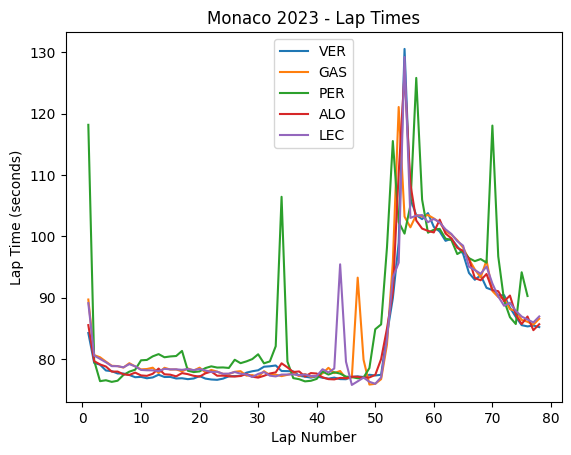

In [7]:
import matplotlib.pyplot as plt
for driver in top5:
  driver_laps=laps[laps['Driver']==driver]
  plt.plot(driver_laps['LapNumber'],
             driver_laps['LapTime'].dt.total_seconds(),
             label=driver)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Monaco 2023 - Lap Times')
plt.legend()
plt.show()

In [8]:
ver_laps = laps[laps['Driver'] == 'VER']
compounds = ver_laps['Compound'].unique()
print(compounds)

['MEDIUM' 'INTERMEDIATE']


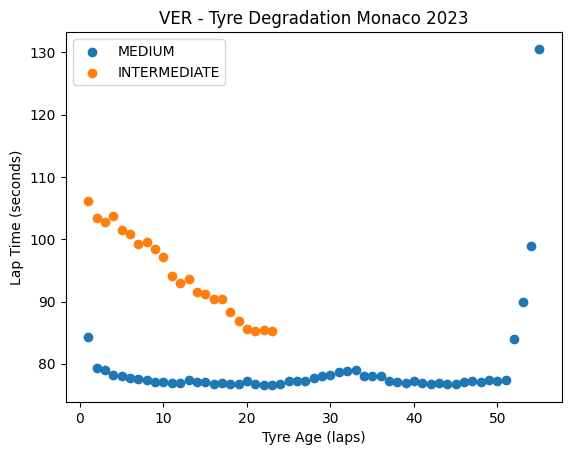

In [9]:
for compound in compounds:
    compound_laps = ver_laps[ver_laps['Compound'] == compound]
    plt.scatter(compound_laps['TyreLife'],
                compound_laps['LapTime'].dt.total_seconds(),
                label=compound)

plt.xlabel('Tyre Age (laps)')
plt.ylabel('Lap Time (seconds)')
plt.title('VER - Tyre Degradation Monaco 2023')
plt.legend()
plt.show()